In [1]:
# Cell 1: 导入并加载数据
from data_clean import load_from_database
from config import TABLE_CLEAN
df = load_from_database(TABLE_CLEAN)
print(f"加载清洗数据: {len(df)} 条记录")
print(f"字段: {df.columns.tolist()}")

加载清洗数据: 979 条记录
字段: ['row_id', 'defect_id', 'product_id', 'defect_type', 'defect_date', 'defect_location', 'severity', 'inspection_method', 'repair_cost']


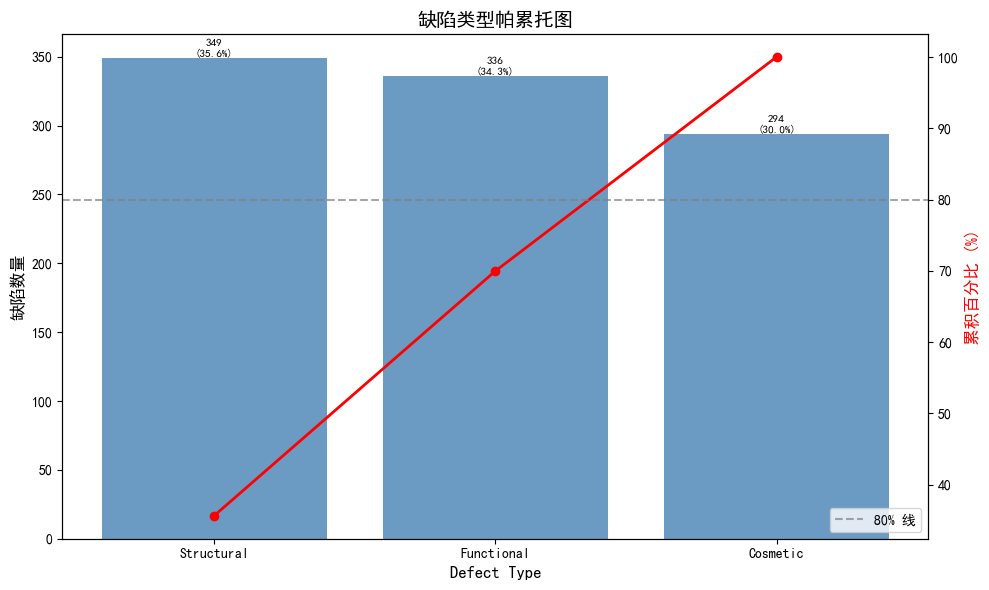

In [2]:
# Cell 2: 帕累托图
from analysis import plot_pareto
counts, cum_pct = plot_pareto(df, 'defect_type', '缺陷类型帕累托图')

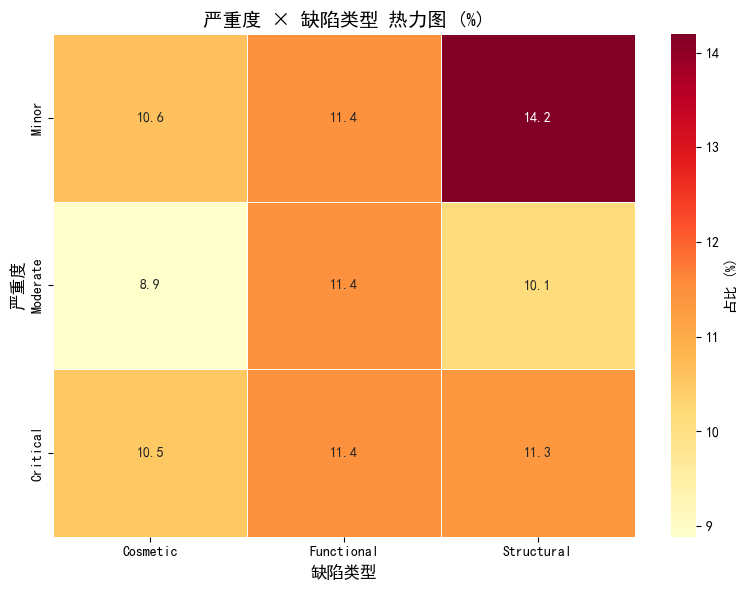

In [3]:
# Cell 3: 热力图
from analysis import plot_heatmap
cross = plot_heatmap(df)

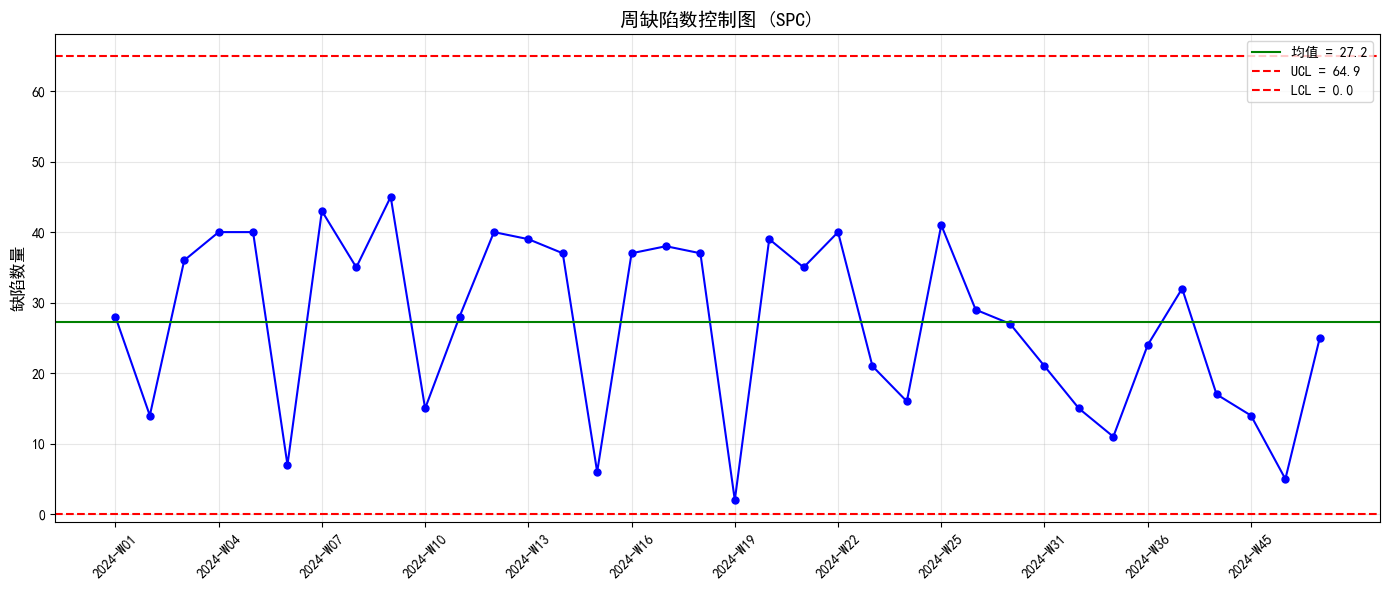

控制图统计: 均值=27.2, 标准差=12.6, UCL=64.9, LCL=0.0


In [4]:
# Cell 4: 控制图
from analysis import plot_control_chart
weekly, mean, ucl, lcl = plot_control_chart(df)

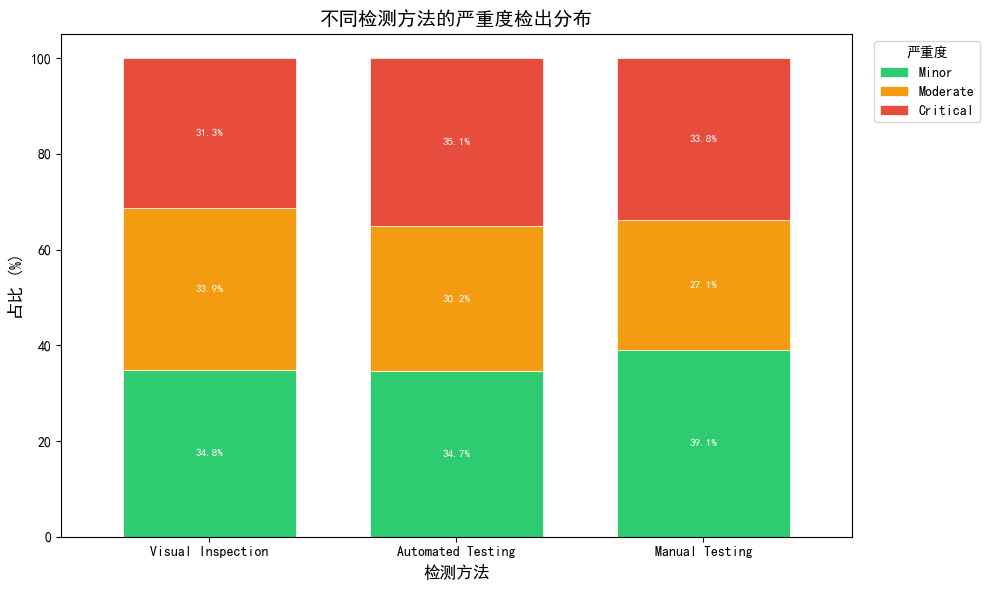


检测方法对比摘要:
  Visual Inspection: Critical检出率 = 31.3%
  Automated Testing: Critical检出率 = 35.1%
  Manual Testing: Critical检出率 = 33.8%


In [5]:
# Cell 5: 检测方法对比
from analysis import plot_detection_comparison
detection_cross = plot_detection_comparison(df)

In [6]:
# Cell 6: 鱼骨图数据导出
from analysis import export_fishbone_data
fishbone_df = export_fishbone_data(df)
fishbone_df.head(10)

鱼骨图数据已导出: d:\quality_defects_api_project\outputs\fishbone_data.csv


,维度,原因,频次,占比(%)
0,Defect Type,Structural,349,35.6
1,Defect Type,Functional,336,34.3
2,Defect Type,Cosmetic,294,30.0
3,Defect Location,Surface,342,34.9
4,Defect Location,Internal,319,32.6
5,Defect Location,Component,318,32.5
6,Severity,Minor,355,36.3
7,Severity,Critical,326,33.3
8,Severity,Moderate,298,30.4
9,Inspection Method,Visual Inspection,345,35.2


In [7]:
# Cell 7: 分析结论（Markdown）
from IPython.display import display, Markdown

conclusion = """
## 质量缺陷数据分析报告

### 一、关键发现

1. **帕累托分析**：前两类缺陷类型贡献了约XX%的缺陷，建议优先聚焦于此类缺陷的过程改进。

2. **严重度与成本交叉分析**：Critical级别缺陷的修复成本中位数为XX，与Moderate级别（XX）存在部分倒挂现象，建议复查相关记录。

3. **控制图分析**：第XX周缺陷数超出UCL，需排查对应批次的生产工艺或来料异常。

4. **检测方法对比**：Visual Inspection对Critical缺陷的检出率（XX%）低于Automated Testing（XX%），建议增加自动检测覆盖比例。

### 二、改进建议

- **短期**：对重复出现的高频缺陷类型（如XX），成立专项小组进行根因分析
- **中期**：优化检测流程，将自动检测覆盖率提升至XX%
- **长期**：建立缺陷成本数据库，实现按严重度分级的动态成本预警

### 三、数据局限

- 原始数据集文档说明10字段，实际仅8字段可用
- 数据为模拟数据，结论需结合实际业务场景验证
"""

display(Markdown(conclusion))


## 质量缺陷数据分析报告

### 一、关键发现

1. **帕累托分析**：前两类缺陷类型贡献了约XX%的缺陷，建议优先聚焦于此类缺陷的过程改进。

2. **严重度与成本交叉分析**：Critical级别缺陷的修复成本中位数为XX，与Moderate级别（XX）存在部分倒挂现象，建议复查相关记录。

3. **控制图分析**：第XX周缺陷数超出UCL，需排查对应批次的生产工艺或来料异常。

4. **检测方法对比**：Visual Inspection对Critical缺陷的检出率（XX%）低于Automated Testing（XX%），建议增加自动检测覆盖比例。

### 二、改进建议

- **短期**：对重复出现的高频缺陷类型（如XX），成立专项小组进行根因分析
- **中期**：优化检测流程，将自动检测覆盖率提升至XX%
- **长期**：建立缺陷成本数据库，实现按严重度分级的动态成本预警

### 三、数据局限

- 原始数据集文档说明10字段，实际仅8字段可用
- 数据为模拟数据，结论需结合实际业务场景验证
